In [6]:
%load_ext autoreload
%autoreload 2
from train import *
import fourier_modules as FM
import matplotlib.pyplot as plt
from torchvision.utils import make_grid,save_image
import math
dir_fig='./images/figures/'

reproduce=True #flag to reproduce the exact same results as in the paper. 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Synthesis at training size and at twice the training size ($\rho=1$ and $\rho=2$), with visualization of features
For each image and method, a batch is processed, and results are saved under `./images/figures/2x/$image/$batch/`
This cell reproduces Fig.5 of the paper.

In [7]:
# this code can also be used to visualize the DFT of the feature maps. This was drop in the paper for simplicity.
methods=['FU','fomonms_size_3_EMN_1_CA_1','UFU','Vanilla']

B=8   # batch size
col=4 # number of feature maps to plot 

for img0 in [str(i) for i in range(1,16)]:
    for method in methods:
        for d in os.listdir('./runs'):
            if img0 == d.split('_')[1] and method in d:
                if method=='FU' and 'UFU' in d:
                    break
                if 'fomo' in d and 'EMN_1_CA_1' in d:
                    name=d
                    break
                name=d
        if method=='Attention':
            pass
            #continue
        
        with torch.no_grad():
            parser = argparse.ArgumentParser()
            args ,_= parser.parse_known_args()
            args=load_args(os.path.join('./runs',name,'args.json'),args)
            dir_inf=os.path.join('runs',name,'inference')
            os.makedirs(dir_inf,exist_ok=True)
            
            FM.CA=args.CA
            FM.EMN=args.EMN
            dset=DS_rot(args.dataset_path,image_size=(args.img_size,args.img_size),min_mask_shape=(64,64),max_mask_shape=(200,200))
            loader=DataLoader(dset,batch_size=args.bs,shuffle=True,drop_last=True,num_workers=0)
            M = Model(nc_im=3,nc_start=args.dim,nc_max=512,depth=args.depth,fourier_mode=args.fourier_mode,train_size=(args.img_size,args.img_size),nms_size=args.nms_size).to(device)
            M.eval()
            #print(name,method,args.fourier_mode,n_params(M)/10**6,'M parameters')
            torch.manual_seed(0) if reproduce else torch.seed()
            x_plot,mask_plot=next(iter(loader))
            x_plot,mask_plot=x_plot.to(device),mask_plot.to(device)
            masked_plot=x_plot*mask_plot
            n_plot=torch.randn_like(masked_plot)
            b,c,h,w=x_plot.shape
            ratio=(2,2)
            x_plot2x=F.pad(x_plot,(((ratio[1]-1)*w)//2,((ratio[1]-1)*w)-((ratio[1]-1)*w)//2,((ratio[0]-1)*h)//2,((ratio[0]-1)*h)-((ratio[0]-1)*h)//2))
            mask_plot2x=F.pad(mask_plot,(((ratio[1]-1)*w)//2,((ratio[1]-1)*w)-((ratio[1]-1)*w)//2,((ratio[0]-1)*h)//2,((ratio[0]-1)*h)-((ratio[0]-1)*h)//2))
            masked_plot2x=x_plot2x*mask_plot2x
            n_plot2x=torch.randn_like(masked_plot2x)


            try:
                M.load_state_dict(torch.load(os.path.join('runs',name,'M.pth')),strict=False) 
            except:
                print('model not loaded!')
                pass

            if 'fomo' in args.fourier_mode.lower(): # For FoMo-NMS, plot the most important feature maps based on the $\lambda$ values.
                lam=M.Fourier_module.block.lam 
                _,idx=torch.sort(lam.abs(),dim=1,descending=True) 
                #plt.figure(figsize=(10,5))
                #plt.title('Distribution of $\lambda$ values in FoMo-NMS')
                #plt.hist(lam.abs().cpu().numpy().flatten(),bins=20,density=True)


            rec=M(n_plot,mask_plot,masked_plot)

            f=FM.features['%s_in'%args.fourier_mode]
            if 'fomo' in args.fourier_mode.lower(): 
                f=f[:,idx.view(-1)]
            fmin,fmax=f.view(f.shape[0],f.shape[1],-1).sort(dim=-1)[0][...,20:-20].min(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1),f.view(f.shape[0],f.shape[1],-1).sort(dim=-1)[0][...,100:-100].max(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1)
            f_in=((f-fmin)/(fmax-fmin)).clamp(0,1)
            m=torch.log1p(fft.fftshift(fft.fft2(f-f.mean(dim=(-2,-1)).unsqueeze(-1).unsqueeze(-1),norm='backward'),dim=(-2,-1)).abs())
            m=(m-m.view(m.shape[0],m.shape[1],-1).min(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1))/(m.view(m.shape[0],m.shape[1],-1).max(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1)-m.view(m.shape[0],m.shape[1],-1).min(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1))
            m_in=1.*m

            f=FM.features['%s_out'%args.fourier_mode]
            if 'fomo' in args.fourier_mode.lower():
                f=f[:,idx.view(-1)]
            fmin,fmax=f.view(f.shape[0],f.shape[1],-1).sort(dim=-1)[0][...,20:-20].min(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1),f.view(f.shape[0],f.shape[1],-1).sort(dim=-1)[0][...,100:-100].max(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1)
            f_out=((f-fmin)/(fmax-fmin)).clamp(0,1)
            m=torch.log1p(fft.fftshift(fft.fft2(f-f.mean(dim=(-2,-1)).unsqueeze(-1).unsqueeze(-1),norm='backward'),dim=(-2,-1)).abs())
            tmp = torch.where(m >1e-4, m, torch.full_like(m, float('inf')))
            min_vals = tmp.amin(dim=(-2, -1), keepdim=True)
            m = torch.where(m > 1e-4, m, m - min_vals)
            m_out=(m-m.view(m.shape[0],m.shape[1],-1).min(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1))/(m.view(m.shape[0],m.shape[1],-1).max(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1)-m.view(m.shape[0],m.shape[1],-1).min(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1))
            m_out=m_out**4

            fm=torch.cat((torch.cat([f_in,f_out],dim=-2),torch.cat([m_in,m_out],dim=-2)),dim=-1)
            fm=F.interpolate(fm,size=(rec.shape[-2]//1,2*x_plot.shape[-1]//2),mode='nearest')
            for b in range(B):
                img = rec[b:b+1].clone()  
                mask = mask_plot[b] 
                ys, xs = torch.where(mask[0] > 0)
                y1, y2 = ys.min(), ys.max()
                x1, x2 = xs.min(), xs.max()
                for t in [0, 1]:
                    img[:, 0, y1:y2+1, x1+t] = 0.0
                    img[:, 0, y1:y2+1, x2-t] = 0.0
                    img[:, 0, y1+t, x1:x2+1] = 0.0
                    img[:, 0, y2-t, x1:x2+1] = 0.0
                    img[:, 1:, y1:y2+1, x1+t] = 0
                    img[:, 1:, y1:y2+1, x2-t] = 0
                    img[:, 1:, y1+t, x1:x2+1] = 0
                    img[:, 1:, y2-t, x1:x2+1] = 0
                i1 = make_grid(img,nrow=1,padding=0)
                i2 = make_grid(torch.cat([fm[b, i] for i in range(col)], dim=-1).unsqueeze(0).unsqueeze(1).repeat(1, 3, 1, 1),nrow=1,padding=0)
                grid = torch.cat([i1, i2], dim=-1).permute(0,2,1)
                os.makedirs(os.path.join(dir_fig,'2x',img0,str(b)),exist_ok=True)
                save_image(grid.permute(0, 2, 1),os.path.join(dir_fig,'2x',img0,str(b), "%s.png"%args.fourier_mode))

            # extended size
            rec=M(n_plot2x,mask_plot2x,masked_plot2x)
            im= torch.cat((make_grid(x_plot2x+.3*mask_plot2x),make_grid(rec)),dim=-2).cpu()
            #save_image(im,os.path.join(dir_inf,'%s_2x.png'%args.fourier_mode))

            f=FM.features['%s_in'%args.fourier_mode]
            if 'fomo' in args.fourier_mode.lower():
                f=f[:,idx.view(-1)]
            fmin,fmax=f.view(f.shape[0],f.shape[1],-1).sort(dim=-1)[0][...,20:-20].min(dim=-1)[0].unsqueeze(-1).unsqueeze(-1),f.view(f.shape[0],f.shape[1],-1).sort(dim=-1)[0][...,100:-100].max(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1)
            f_in=((f-fmin)/(fmax-fmin)).clamp(0,1)
            m=torch.log1p(fft.fftshift(fft.fft2(f-f.mean(dim=(-2,-1)).unsqueeze(-1).unsqueeze(-1),norm='backward'),dim=(-2,-1)).abs())
            m=(m-m.view(m.shape[0],m.shape[1],-1).min(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1))/(m.view(m.shape[0],m.shape[1],-1).max(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1)-m.view(m.shape[0],m.shape[1],-1).min(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1))
            m_in=1.*m

            f=FM.features['%s_out'%args.fourier_mode]
            if 'fomo' in args.fourier_mode.lower():
                f=f[:,idx.view(-1)]
            fmin,fmax=f.view(f.shape[0],f.shape[1],-1).sort(dim=-1)[0][...,20:-20].min(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1),f.view(f.shape[0],f.shape[1],-1).sort(dim=-1)[0][...,100:-100].max(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1)
            f_out=((f-fmin)/(fmax-fmin)).clamp(0,1)
            m=torch.log1p(fft.fftshift(fft.fft2(f-f.mean(dim=(-2,-1)).unsqueeze(-1).unsqueeze(-1),norm='backward'),dim=(-2,-1)).abs())
            tmp = torch.where(m >1e-4, m, torch.full_like(m, float('inf')))
            min_vals = tmp.amin(dim=(-2, -1), keepdim=True)
            m = torch.where(m > 1e-4, m, m - min_vals)
            m_out=(m-m.view(m.shape[0],m.shape[1],-1).min(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1))/(m.view(m.shape[0],m.shape[1],-1).max(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1)-m.view(m.shape[0],m.shape[1],-1).min(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1))
            m_out=m_out**4

            fm=torch.cat((torch.cat([f_in,f_out],dim=-2),torch.cat([m_in,m_out],dim=-2)),dim=-1)
            fm=torch.cat([f_in,f_out],dim=-2)
            fm=F.interpolate(fm,size=(rec.shape[-2]//1,x_plot2x.shape[-1]//2),mode='nearest')
            for b in range(B):
                img = rec[b:b+1].clone()  
                mask = mask_plot2x[b]
                ys, xs = torch.where(mask[0] > 0)
                y1, y2 = ys.min(), ys.max()
                x1, x2 = xs.min(), xs.max()
                for t in [0, 1]:
                    img[:, 0, y1:y2+1, x1+t] = 0.0
                    img[:, 0, y1:y2+1, x2-t] = 0.0
                    img[:, 0, y1+t, x1:x2+1] = 0.0
                    img[:, 0, y2-t, x1:x2+1] = 0.0
                    img[:, 1:, y1:y2+1, x1+t] = 0
                    img[:, 1:, y1:y2+1, x2-t] = 0
                    img[:, 1:, y1+t, x1:x2+1] = 0
                    img[:, 1:, y2-t, x1:x2+1] = 0
                i1 = make_grid(img,nrow=1,padding=0)
                i2 = make_grid(torch.cat([fm[b, i] for i in range(col)], dim=-1).unsqueeze(0).unsqueeze(1).repeat(1, 3, 1, 1),nrow=1,padding=0)
                grid = torch.cat([i1, i2], dim=-1).permute(0,2,1)
                os.makedirs(os.path.join(dir_fig,'2x',img0,str(b)),exist_ok=True)
                save_image(grid.permute(0, 2, 1),os.path.join(dir_fig,'2x',img0,str(b),'%s_2x.png'%(args.fourier_mode)))










img_1_FU FU FU 0.706147 M parameters


/tmp/ipykernel_91864/1379026118.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  M.load_state_dict(torch.load(os.path.join('runs',name,'M.pth')),strict=False)


img_1_fomonms_size_3_EMN_1_CA_1 fomonms_size_3_EMN_1_CA_1 fomonms 0.640227 M parameters
img_1_UFU_official UFU UFU_official 1.300388 M parameters
img_1_Vanilla Vanilla Vanilla 0.640099 M parameters
img_2_FU FU FU 0.706147 M parameters
img_2_fomonms_size_3_EMN_1_CA_1 fomonms_size_3_EMN_1_CA_1 fomonms 0.640227 M parameters
img_2_UFU_official UFU UFU_official 1.300388 M parameters
img_2_Vanilla Vanilla Vanilla 0.640099 M parameters
img_3_FU FU FU 0.706147 M parameters
img_3_fomonms_size_3_EMN_1_CA_1 fomonms_size_3_EMN_1_CA_1 fomonms 0.640227 M parameters
img_3_UFU_official UFU UFU_official 1.300388 M parameters
img_3_Vanilla Vanilla Vanilla 0.640099 M parameters
img_4_FU FU FU 0.706147 M parameters
img_4_fomonms_size_3_EMN_1_CA_1 fomonms_size_3_EMN_1_CA_1 fomonms 0.640227 M parameters
img_4_UFU_official UFU UFU_official 1.300388 M parameters
img_4_Vanilla Vanilla Vanilla 0.640099 M parameters
img_5_FU FU FU 0.706147 M parameters
img_5_fomonms_size_3_EMN_1_CA_1 fomonms_size_3_EMN_1_CA_1 fo

# Complex mask
This code reproduces FIg.6 of the paper. To save intermediate feature visualization, the code of the FoMo-NMS module is copied in this cell.

/home/chatill243/anaconda3/envs/simulditex/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647378361/work/aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/tmp/ipykernel_91864/2840056173.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode un

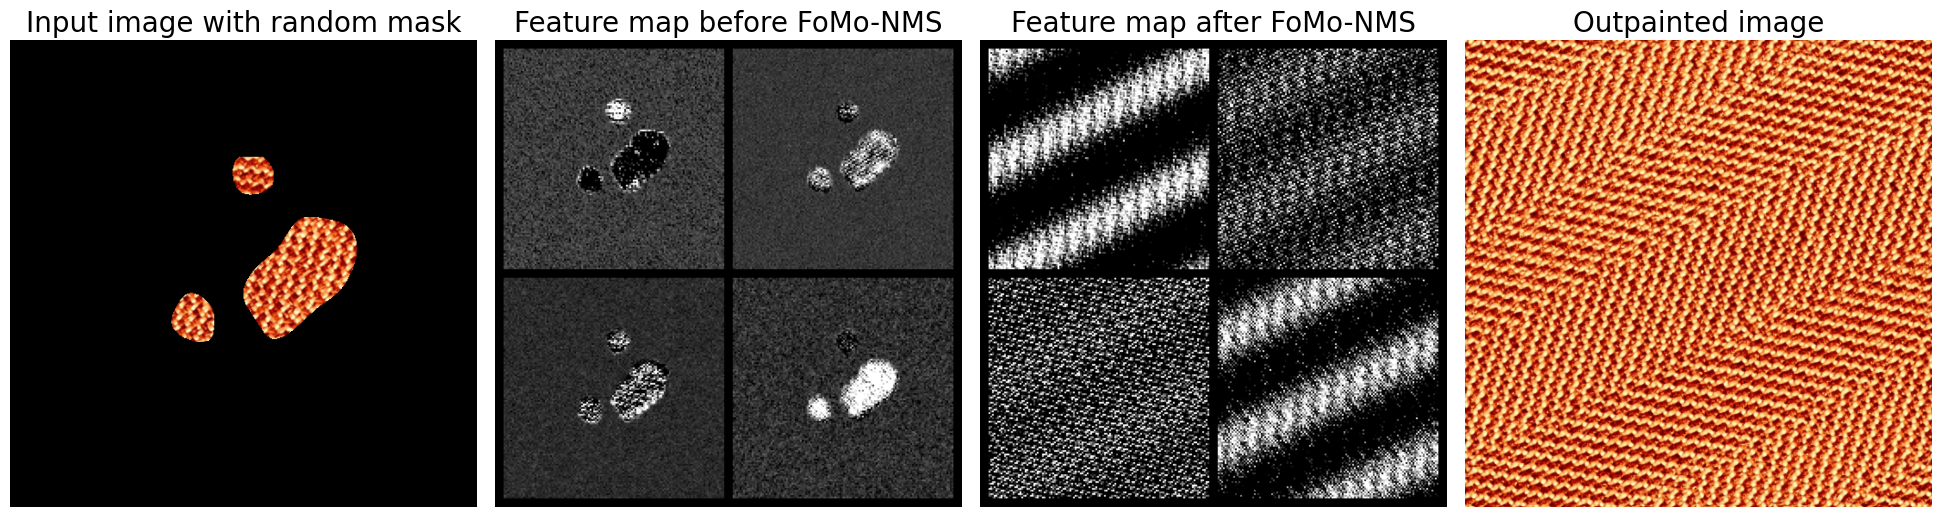

In [8]:
method='fomonms_nms_size_3'
img0='7'
B=1

for d in os.listdir('./runs'):
    if img0 == d.split('_')[1] and 'fomonms_size_3_EMN_1_CA_1' in d:
        name=d

with torch.no_grad():
    parser = argparse.ArgumentParser()
    args ,_= parser.parse_known_args()
    args=load_args(os.path.join('./runs',name,'args.json'),args)
    torch.manual_seed(args.seed) if reproduce else torch.seed()
    FM.CA=args.CA
    FM.EMN=args.EMN
    dset=DS_rot(args.dataset_path,image_size=(args.img_size,args.img_size),min_mask_shape=(64,64),max_mask_shape=(200,200))
    loader=DataLoader(dset,batch_size=args.bs,shuffle=True,drop_last=True,num_workers=0)
    M = Model(nc_im=3,nc_start=args.dim,nc_max=512,depth=args.depth,fourier_mode=args.fourier_mode,train_size=(args.img_size,args.img_size),nms_size=args.nms_size).to(device)
    M.eval()



    x_plot,mask_plot=next(iter(loader))

    import torch.nn.functional as F
    noise = torch.randn_like(x_plot[:, :1])
    kernel_size = 151
    xx,yy = torch.meshgrid(torch.arange(kernel_size), torch.arange(kernel_size))
    kernel = torch.exp(-((xx - kernel_size//2)**2 + (yy - kernel_size//2)**2) / (2 * (kernel_size/6)**2))
    kernel = kernel / kernel.sum()  # Normalize the kernel
    kernel = kernel.unsqueeze(0).unsqueeze(0).to(noise.device)
    blurred_noise = F.conv2d(noise, kernel, padding=kernel_size // 2)
    # penalize the borders, increase value close to the center
    xx,yy= torch.meshgrid(torch.arange(noise.shape[-2]),torch.arange(noise.shape[-1]))
    penalization = -(xx-noise.shape[-2]//2)**2-(yy-noise.shape[-1]//2)**2
    penalization=penalization*1.
    penalization = (penalization-penalization.mean())/penalization.std()
    blurred_noise = (blurred_noise-blurred_noise.mean()) / blurred_noise.std()
    mask_plot = ((blurred_noise+.5*penalization) > 1.).float()
    


    x_plot,mask_plot=x_plot.to(device),mask_plot.to(device)



    masked_plot=x_plot*mask_plot
    n_plot=torch.randn_like(masked_plot)
    b,c,h,w=x_plot.shape

    ratio=(2,2)
    x_plot2x=F.pad(x_plot,(((ratio[1]-1)*w)//2,((ratio[1]-1)*w)-((ratio[1]-1)*w)//2,((ratio[0]-1)*h)//2,((ratio[0]-1)*h)-((ratio[0]-1)*h)//2))
    mask_plot2x=F.pad(mask_plot,(((ratio[1]-1)*w)//2,((ratio[1]-1)*w)-((ratio[1]-1)*w)//2,((ratio[0]-1)*h)//2,((ratio[0]-1)*h)-((ratio[0]-1)*h)//2))




    masked_plot2x=x_plot2x*mask_plot2x
    n_plot2x=torch.randn_like(masked_plot2x)






    x_plot,mask_plot,masked_plot,n_plot=x_plot2x,mask_plot2x,masked_plot2x,n_plot2x
    try:
        M.load_state_dict(torch.load(os.path.join('runs',name,'M.pth')),strict=False) 
    except:
        print('model not loaded!')
        pass

    if 'fomo' in args.fourier_mode.lower():
        lam=M.Fourier_module.block.lam 
        _,idx=torch.sort(lam.abs(),dim=1,descending=True)
        idx=idx.flatten()
    


    #
    save_image(masked_plot[0].cpu().detach(), os.path.join(dir_fig,'random_masked.png')) 
    save_image(mask_plot[0].cpu().detach(), os.path.join(dir_fig,'random_mask.png'))

    x=M.enc(torch.cat((n_plot,masked_plot,mask_plot),dim=1))
    feat_in=x*1.
    lam=M.Fourier_module.block.lam
    pos_channel=torch.argmax(lam.abs(),dim=1).squeeze()
    
    batch, c, h, w = x.size()
    nms_size=M.Fourier_module.block.nms_size
    rho_x,rho_y=h//M.Fourier_module.block.ref_size[0],w//M.Fourier_module.block.ref_size[1]

    ffted = torch.fft.fft2(x-x.mean(dim=(2,3), keepdim=True), dim=(-2,-1), norm='backward')              # FFT2
    phase=torch.angle(ffted)                                             # Store phase for later
    
    mod=ffted.abs()
    norm=(mod**2).sum(dim=(-2,-1),keepdim=True)**.5                
    for i in range(1):
        feats_before=make_grid(x[:1,idx[:4]].permute(1,0,2,3).cpu().detach(),nrow=2,padding=5).permute(1,2,0)
        save_image(x[0,idx[i]].cpu().detach(),os.path.join(dir_fig,'random_mask_feats.png'),normalize=True )

    if True:
    
        mask = F.interpolate(mask_plot, (h, w), mode='nearest')  # (B,1,H,W)
        k = 0
        mask_pad = F.pad(mask, (k, k, k, k), mode='circular')
        eroded = -F.max_pool2d(-mask_pad, kernel_size=2*k+1, stride=1)
        eroded = eroded.expand_as(x)
        n1 = eroded.sum((2,3), keepdim=True).clamp(min=1)
        mean = (x * eroded).sum((2,3), keepdim=True) / n1  

        x= x*eroded -mean*eroded
    for i in range(1):
        save_image(.5+x[0,idx[i]].cpu().detach()/max(x[0,idx[i]].max(),-x[0,idx[i]].min()).cpu().detach(), os.path.join(dir_fig,'random_mask_feats_EMN.png') )

    ffted = torch.fft.fft2(x, dim=(-2,-1), norm='backward')              # FFT2
    phase=torch.angle(ffted)                                             # Store phase for later
    mod=ffted.abs()
    norm=(mod**2).sum(dim=(-2,-1),keepdim=True)**.5



    #Non maximum suppression: kernel size stretched to match a fixed ratio of input size
    mp_size=((nms_size*rho_x)//2*2+1,(nms_size*rho_y)//2*2+1)                                                # make NMS kernel size proportional to input size, and odd

    mp=nn.MaxPool2d(mp_size,stride=(1,1),padding=((nms_size*rho_x)//2,(nms_size*rho_y)//2))

    if True:
        mean_mod=(mod*lam).sum(dim=(1),keepdim=True)                                                        # NMS on the mean across channels, weighted with their learnable importance.
        
        nms_mask=(mp(fft.fftshift(mean_mod,dim=(-2,-1)))==fft.fftshift(mean_mod,dim=(-2,-1)))                    # Effectively compute the NMS mask in a periodic manner.
        nms_mask=fft.ifftshift(nms_mask,dim=(-2,-1))
        nms_mask=((mp(mean_mod)==mean_mod) * nms_mask)*1                           
    
    new_mod=mod*nms_mask       
    new_mod=new_mod*norm/(new_mod**2).sum(dim=(-2,-1),keepdim=True)**.5*mask_plot.mean(dim=(2,3),keepdim=True)**-.5  # Mask-adaptive renormalization
    new_f = new_mod*torch.exp(1.j*phase)                               # re-inject the phase
    output = fft.ifft2(new_f,dim=(-2,-1),norm='backward').real         # iFTTT2
    res = output*lam.abs()   
    for i in range(1):
        feats_after=make_grid(res[:1,idx[:4]].permute(1,0,2,3).cpu().detach(),nrow=2,padding=5).permute(1,2,0)
        save_image(res[0,idx[i]].cpu().detach(), os.path.join(dir_fig,'random_mask_feats_NMS.png'),normalize=True )
    out=torch.sigmoid(M.dec(feat_in+res))
    save_image(out[0].cpu().detach(), os.path.join(dir_fig,'random_mask_rec.png'))


plt.figure(figsize=(20,5))

fontsize=20
plt.subplot(1,4,1)
plt.title('Input image with random mask',fontsize=fontsize)
plt.imshow(masked_plot[0].cpu().permute(1,2,0))
plt.axis('off')
plt.subplot(1,4,2)
plt.title('Feature map before FoMo-NMS',fontsize=fontsize)
plt.imshow(feats_before.cpu())
plt.axis('off')
plt.subplot(1,4,3)
plt.title('Feature map after FoMo-NMS',fontsize=fontsize)
plt.imshow(feats_after.cpu())
plt.axis('off')
plt.subplot(1,4,4)
plt.title('Outpainted image',fontsize=fontsize)
plt.imshow(out[0].cpu().permute(1,2,0))
plt.axis('off')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.tight_layout(pad=0.1, w_pad=0.0, h_pad=0.0)
plt.savefig(os.path.join(dir_fig,'random_mask_comparison.png'))
plt.show()












# More complex masks outpainting
This cell reproduces all images of Fig.7.\
For each image, two different rotations of the training texture and two random masks are used for outpainting at $\rho=2$. Results are saved under `./images/figures/complex_masks_inpainting/`

In [9]:


save_dir = "./images/figures/complex_masks_inpainting"
os.makedirs(save_dir, exist_ok=True)

method = "fomonms_nms_size_3"

for img0 in range(1, 16):
    torch.manual_seed(img0) if reproduce else torch.seed()

    img0 = str(img0)

    # ------------------------------------------------------------
    # find run
    # ------------------------------------------------------------
    for d in os.listdir("./runs"):
        if img0 == d.split("_")[1] and "fomonms_size_3_EMN_1_CA_1" in d:
            name = d
            break


    # ------------------------------------------------------------
    # load args/model
    # ------------------------------------------------------------
    parser = argparse.ArgumentParser()
    args, _ = parser.parse_known_args()
    args = load_args(os.path.join("./runs", name, "args.json"), args)

    FM.CA = args.CA
    FM.EMN = args.EMN

    dset = DS_rot(
        args.dataset_path,
        image_size=(args.img_size, args.img_size),
        min_mask_shape=(64, 64),
        max_mask_shape=(200, 200),
    )

    loader = DataLoader(
        dset,
        batch_size=2,
        shuffle=True,
        drop_last=True,
        num_workers=0,
    )

    M = Model(
        nc_im=3,
        nc_start=args.dim,
        nc_max=512,
        depth=args.depth,
        fourier_mode=args.fourier_mode,
        train_size=(args.img_size, args.img_size),
        nms_size=args.nms_size,
    ).to(device)

    M.eval()

    M.load_state_dict(
        torch.load(os.path.join("runs", name, "M.pth")),
        strict=False,
    )

    # ------------------------------------------------------------
    # data
    # ------------------------------------------------------------
    x_plot, mask_plot = next(iter(loader))

    # ---- random smooth mask ----
    noise = torch.randn_like(x_plot[:, :1])

    kernel_size = 151

    xx, yy = torch.meshgrid(
        torch.arange(kernel_size),
        torch.arange(kernel_size),
        indexing="ij",
    )

    kernel = torch.exp(
        -(
            (xx - kernel_size // 2) ** 2
            + (yy - kernel_size // 2) ** 2
        )
        / (2 * (kernel_size / 6) ** 2)
    )

    kernel = kernel / kernel.sum()
    kernel = kernel.unsqueeze(0).unsqueeze(0).to(noise.device)

    blurred_noise = F.conv2d(
        noise,
        kernel,
        padding=kernel_size // 2,
    )

    xx, yy = torch.meshgrid(
        torch.arange(noise.shape[-2]),
        torch.arange(noise.shape[-1]),
        indexing="ij",
    )

    penalization = (
        -(xx - noise.shape[-2] // 2) ** 2
        - (yy - noise.shape[-1] // 2) ** 2
    ).float()

    penalization = (
        penalization - penalization.mean()
    ) / penalization.std()

    blurred_noise = (
        blurred_noise - blurred_noise.mean()
    ) / blurred_noise.std()

    mask_plot = (
        (blurred_noise + 1 * penalization) > 0.75
    ).float()

    x_plot = x_plot.to(device)
    mask_plot = mask_plot.to(device)

    # ------------------------------------------------------------
    # upscale
    # ------------------------------------------------------------
    b, c, h, w = x_plot.shape

    ratio = (2, 2)

    x_plot2x = F.pad(
        x_plot,
        (
            ((ratio[1]-1)*w)//2,
            ((ratio[1]-1)*w)-((ratio[1]-1)*w)//2,
            ((ratio[0]-1)*h)//2,
            ((ratio[0]-1)*h)-((ratio[0]-1)*h)//2,
        ),
    )

    mask_plot2x = F.pad(
        mask_plot,
        (
            ((ratio[1]-1)*w)//2,
            ((ratio[1]-1)*w)-((ratio[1]-1)*w)//2,
            ((ratio[0]-1)*h)//2,
            ((ratio[0]-1)*h)-((ratio[0]-1)*h)//2,
        ),
    )

    masked_plot2x = x_plot2x * mask_plot2x
    n_plot2x = torch.randn_like(masked_plot2x)

    # ------------------------------------------------------------
    # inference
    # ------------------------------------------------------------
    with torch.no_grad():
        out =M(
                n_plot2x,
                mask_plot2x,
                masked_plot2x,
        )

    # ------------------------------------------------------------
    # black border around mask
    # ------------------------------------------------------------
    k = 2

    dilated = F.max_pool2d(
        mask_plot2x,
        kernel_size=2*k+1,
        stride=1,
        padding=k,
    )

    eroded = -F.max_pool2d(
        -mask_plot2x,
        kernel_size=2*k+1,
        stride=1,
        padding=k,
    )



    border = ((dilated - eroded) > 0.5).float()

    # expand border to RGB
    border = border.expand_as(out)

    # keep original range, only overwrite border pixels with black
    out_vis = out.clone()
    out_vis[border.bool()] = 0.0

    # ------------------------------------------------------------
    # save
    # ------------------------------------------------------------
    save_image(
        x_plot[0],
        os.path.join(save_dir, f"{img0}_original.png"),
    )

    save_image(
        out_vis[0],
        os.path.join(save_dir, f"{img0}_outpainted.png"),
    )
    save_image(
        x_plot[1],
        os.path.join(save_dir, f"{img0}_original2.png"),
    )

    save_image(
        out_vis[1],
        os.path.join(save_dir, f"{img0}_outpainted2.png"),
    )

/tmp/ipykernel_91864/73285679.py:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(os.path.join("runs", name, "M.pth")),


# Ablation
This cell generates samples for each setup considered in the ablation study of the paper.\
It reproduces Fig.8.
Results are saved under `./images/figures/abalation`

In [11]:
os.makedirs(os.path.join(dir_fig,'ablation'),exist_ok=True)
for name in ['img_'+str(i) for i in range(1,16)]:

    parser = argparse.ArgumentParser()
    args ,_= parser.parse_known_args()
    args=load_args(os.path.join('./runs',name+'_fomonms_size_3_EMN_0_CA_0','args.json'),args)
    torch.manual_seed(args.seed) if reproduce else torch.seed()


    dset=DS_rot(args.dataset_path,image_size=(args.img_size,args.img_size),min_mask_shape=(64,64),max_mask_shape=(200,200))
    loader=DataLoader(dset,batch_size=args.bs,shuffle=True,drop_last=True,num_workers=0)


    x_plot,mask_plot=next(iter(loader))
    x_plot,mask_plot=x_plot.to(device),mask_plot.to(device)
    masked_plot=x_plot*mask_plot
    n_plot=torch.randn_like(masked_plot)
    b,c,h,w=x_plot.shape

    ratio=(2,2)
    x_plot2x=F.pad(x_plot,(((ratio[1]-1)*w)//2,((ratio[1]-1)*w)-((ratio[1]-1)*w)//2,((ratio[0]-1)*h)//2,((ratio[0]-1)*h)-((ratio[0]-1)*h)//2))
    mask_plot2x=F.pad(mask_plot,(((ratio[1]-1)*w)//2,((ratio[1]-1)*w)-((ratio[1]-1)*w)//2,((ratio[0]-1)*h)//2,((ratio[0]-1)*h)-((ratio[0]-1)*h)//2))
    masked_plot2x=x_plot2x*mask_plot2x
    n_plot2x=torch.randn_like(masked_plot2x)

    out=[]
    for CA in (1,0):
        for EMN in (1,0):
            FM.CA=CA
            FM.EMN=EMN
            setup= f'_EMN_{EMN}_CA_{CA}'
                

            parser = argparse.ArgumentParser()
            args ,_= parser.parse_known_args()
            args=load_args(os.path.join('./runs',name+'_fomonms_size_3'+setup,'args.json'),args)

        
            M = Model(nc_im=3,nc_start=args.dim,nc_max=512,depth=args.depth,fourier_mode=args.fourier_mode,train_size=(args.img_size,args.img_size),nms_size=args.nms_size).to(device)
            M.eval()



            try:
                M.load_state_dict(torch.load(os.path.join('runs',name+'_fomonms_size_3'+setup,'M.pth')),strict=False) 
            except:
                print('model not loaded!')
                pass

            with torch.no_grad():
                rec=M(n_plot2x,mask_plot2x,masked_plot2x)
            out.append(rec[0].cpu())
            save_image(rec[0],os.path.join(dir_fig,'ablation',name+f'_CA_{CA}_EMN_{EMN}.png'))

    if False:# optional plot
        fig, axs = plt.subplots(2,3, figsize=(3*ratio[1], 2*ratio[0]))
        names=['MN,CA','no MN, CA','MN, no CA','no MN, no CA']
        axs[0,0].imshow(x_plot2x[0].permute(1,2,0).cpu())
        axs[0,0].axis('off')
        axs[0,0].set_title('original')
        axs[1,0].imshow(masked_plot2x[0].permute(1,2,0).cpu())
        axs[1,0].axis('off')
        axs[1,0].set_title('masked')

        for i, (rec, name) in enumerate(zip(out, names)):


            axs[i//2,1 + i%2].imshow(rec.permute(1,2,0))
            axs[i//2, 1 + i%2].set_title(name)
            axs[i//2, 1 + i%2].axis('off')
        plt.tight_layout()
        plt.show()
FM.CA=1
FM.EMN=1

/tmp/ipykernel_91864/3242854570.py:45: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  M.load_state_dict(torch.load(os.path.join('runs',name+'_fomonms_size_3'+setup,'M.pth')),

# Toy comparison with other modules
In this experiment we work directly with RGB images. We apply diiferent modules (FoMo-NMS, FU, UFU, Attention) directly in pixel space, seeing images as 3 channels feature maps.\
Each module is fed a masked image, and its parameters are trained to reproduce the unmasked hole periodic image.\
Images are the combination of two sine waves with random colors and frequencies.\
We also also verify robustness to noise by adding small white noise to the images, and the masked images.\
This reproduces Fig.3 of the paper. Results are stored under  `./images/figures/comparison/`

100%|██████████| 300/300 [00:11<00:00, 27.05it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.13644701..1.105691].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.019113362..1.065093].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.27973783..1.3225715].


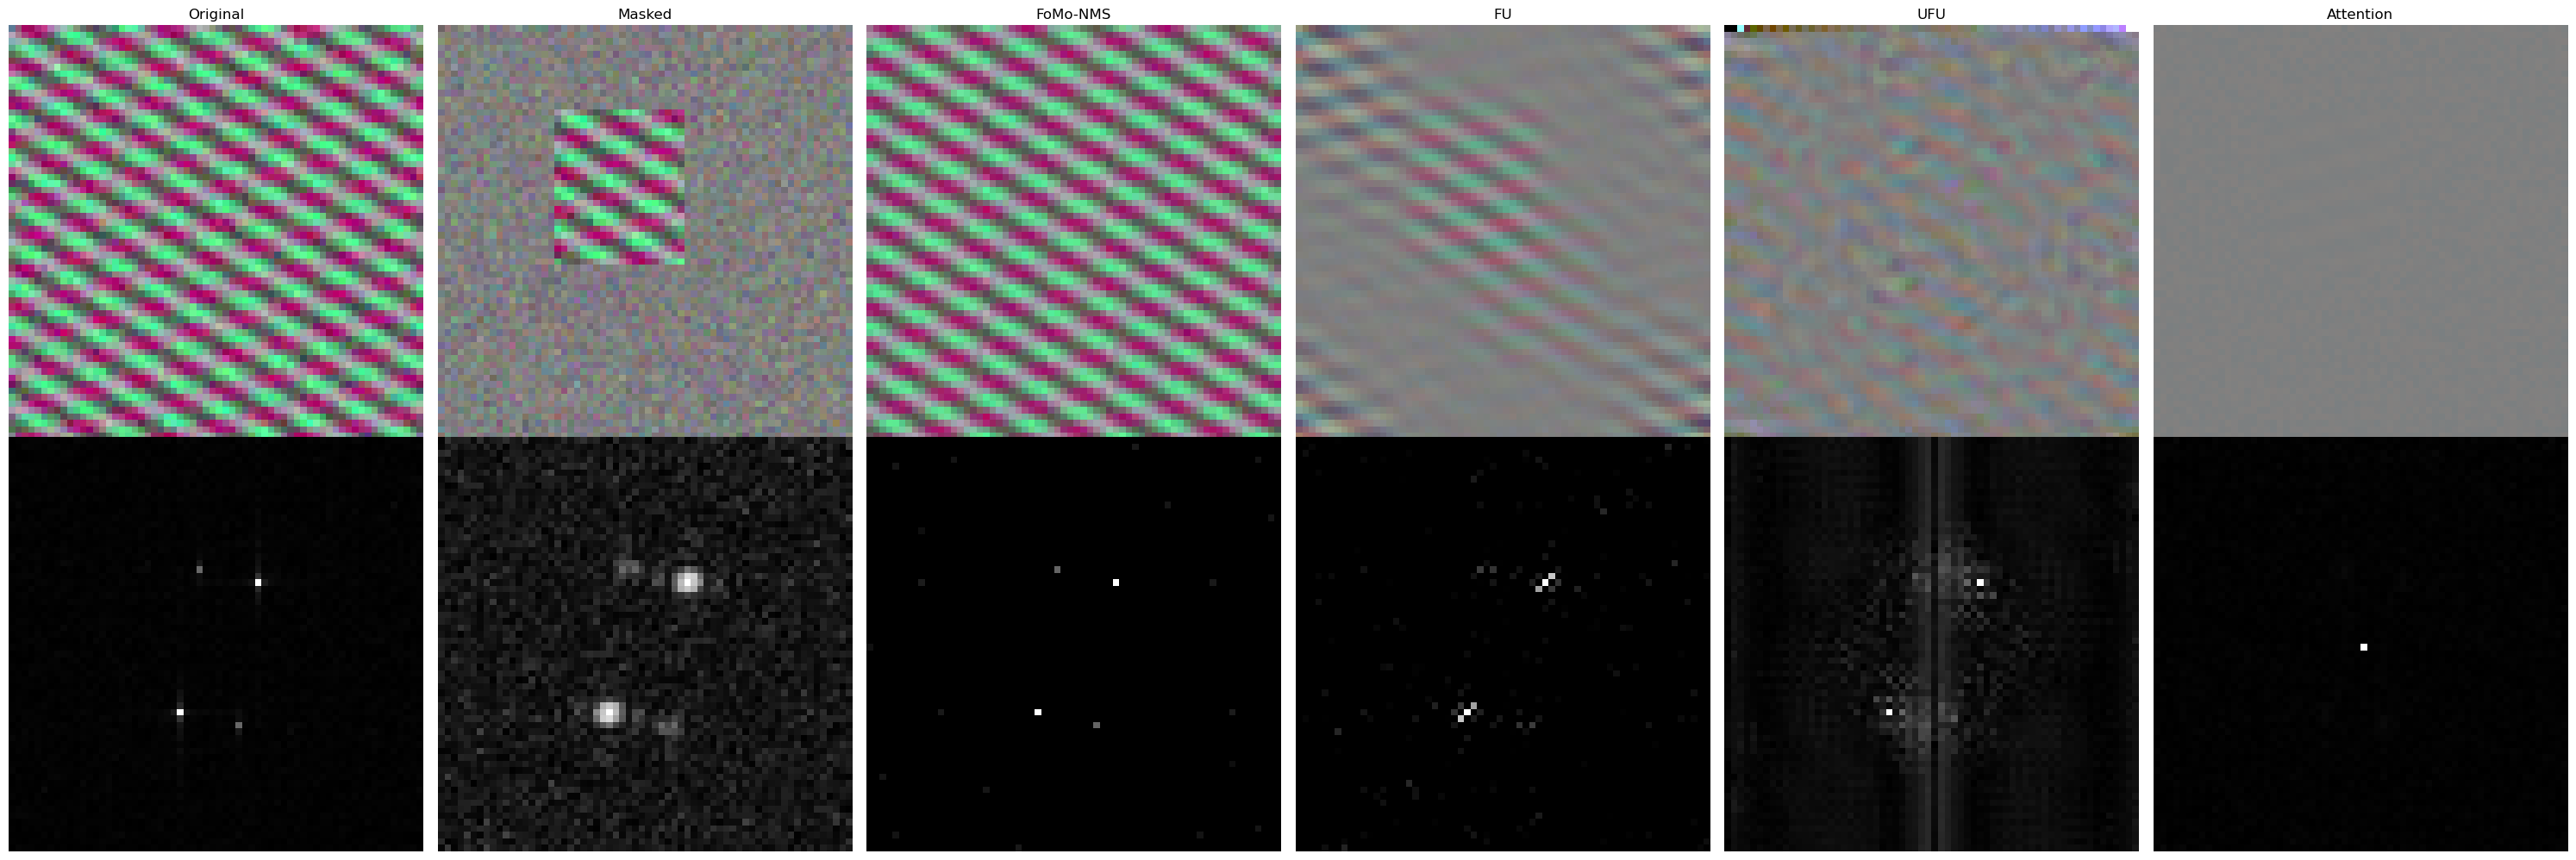

In [12]:
FM.CA=0
FM.EMN=1
torch.manual_seed(0) if reproduce else torch.seed()
C, H, W = 3, 64,64
os.makedirs(os.path.join(dir_fig,'comparison'), exist_ok=True)

# grid in [0,1]
y, x = torch.meshgrid(
    torch.linspace(0, 1, H),
    torch.linspace(0, 1, W),
    indexing="ij"
)



nms = FM.FoMoNMS(in_channels=C, out_channels=C, ref_size=(H,W),nms_size=11)
ffc = FM.FourierUnit(in_channels=C, out_channels=C)
ufu = FM.UFU_official(in_channels=C, out_channels=C, ref_size=(H,W), spectral_pos_encoding=True)
att = FM.Attention(C,heads = 1, dim_head = 3)

names = ['FoMo-NMS','FU','UFU','Attention']
modules=[nms,ffc,ufu,att]
opts=[torch.optim.Adam(nms.parameters(), lr=1e-1),torch.optim.Adam(ffc.parameters(), lr=1e-1),torch.optim.Adam(ufu.parameters(), lr=1e-1),torch.optim.Adam(att.parameters(), lr=1e-1)]


for i in tqdm(range(300)):
    #create random image and mask
    norm=torch.rand(1)*8+8
    f1 = torch.rand(2)-.5
    f2 = torch.rand(2)-.5
    f1 = f1 / f1.norm() * norm
    f2 = f2 / f2.norm() * norm
    f1=f1//1
    f2=f2//1
        # waves
    wave1 = torch.sin(2 * torch.pi * (f1[0]*x + f1[1]*y))
    wave2 = torch.sin(2 * torch.pi * (f2[0]*x + f2[1]*y))

    waves = torch.stack([wave1, wave2], dim=0)  # (2, H, W)

    # random color mixing matrix (2 -> 3)
    mix = torch.randn(3, 2)  # (C, num_waves)

    # apply mixing
    img = torch.einsum('cw,whd->chd', mix, waves)  # (3, H, W)

    # normalize (optional but recommended for display)
    img = img / img.abs().max()

    # add batch dim
    img = img.unsqueeze(0)  # (1, 3, H, W)

    
    mask = torch.zeros(1, 1, H, W)
    mask_corner_w=torch.randint(0, W-32, (1,))
    mask_corner_h=torch.randint(0, H-32, (1,))
    mask_w=torch.randint(16, 32, (1,))
    mask_h=torch.randint(16, 32, (1,))
    w0,w1=mask_corner_w,mask_corner_w+mask_w
    h0,h1=mask_corner_h,mask_corner_h+mask_h
    mask[:, :, h0:h1, w0:w1] = 1.0
    img_masked = img * mask +0.1*torch.randn_like(img)
    img=img+0.1*torch.randn_like(img)

    for opt, module in zip(opts, modules):
        opt.zero_grad()
        try:
            x_out = module(img_masked,mask)
        except:
            x_out = module(img_masked)
        if isinstance(x_out, tuple):
            x_out = x_out[1]
        loss = F.mse_loss(x_out, img)
        loss.backward()
        opt.step()

with torch.no_grad():
    recs=[]
    for module in modules:
        try:
            rec=module(img_masked,mask)
        except:
            rec=module(img_masked)
        if isinstance(rec, tuple):
            rec=rec[1]
        recs.append(rec)




def fft_logmag(x):
    f = torch.fft.fft2(x, norm='forward')
    mag = torch.abs(f)
    logmag = torch.log1p(mag)
    logmag = torch.fft.fftshift(logmag)
    return logmag


fig, axs = plt.subplots(2, 6, figsize=(30,10))

def normalize01(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

# --- original ---
im = img[0]
rgb = im * .5 + .5

axs[0,0].imshow(rgb.permute(1,2,0))
axs[0,0].set_title('Original')
axs[0,0].axis('off')
save_image(rgb, os.path.join(dir_fig,'comparison','rgb_original.png'))

log = fft_logmag(im.unsqueeze(0))[0,0]
log_n = normalize01(log)

axs[1,0].imshow(log_n.cpu(), cmap='gray')
axs[1,0].axis('off')
save_image(log_n.unsqueeze(0), os.path.join(dir_fig,'comparison','log_original.png'))

# --- masked ---
im = img_masked[0]
rgb = im * .5 + .5

axs[0,1].imshow(rgb.permute(1,2,0))
axs[0,1].set_title('Masked')
axs[0,1].axis('off')
save_image(rgb, os.path.join(dir_fig,'comparison','rgb_masked.png'))

log = fft_logmag(im.unsqueeze(0))[0,0]
log_n = normalize01(log)

axs[1,1].imshow(log_n.cpu(), cmap='gray')
axs[1,1].axis('off')
save_image(log_n.unsqueeze(0), os.path.join(dir_fig,'comparison','log_masked.png'))

# --- reconstructions ---
for i, (rec, name) in enumerate(zip(recs, names)):
    im = rec[0]
    rgb = im * .5 + .5

    # RGB
    axs[0,i+2].imshow(rgb.cpu().permute(1,2,0))
    axs[0,i+2].set_title(name)
    axs[0,i+2].axis('off')
    save_image(rgb, os.path.join(dir_fig, 'comparison', f'rgb_{name}.png'))

    # LOG FFT
    log = fft_logmag(im.unsqueeze(0))[0,0]
    log_n = normalize01(log)

    axs[1,i+2].imshow(log_n.cpu(), cmap='gray')
    axs[1,i+2].axis('off')
    save_image(log_n.unsqueeze(0), os.path.join(dir_fig, 'comparison', f'log_{name}.png'))

plt.tight_layout()
plt.savefig(os.path.join(dir_fig, 'comparison.png'))

# 1D toy examples
This cell creates the plot in Fig.2 of the paper. The experiment shows the effectiveness of the proposed signal processing approach on a toy case, and shows the shortcomings of failing to achieve sparsity in the frequency domain.

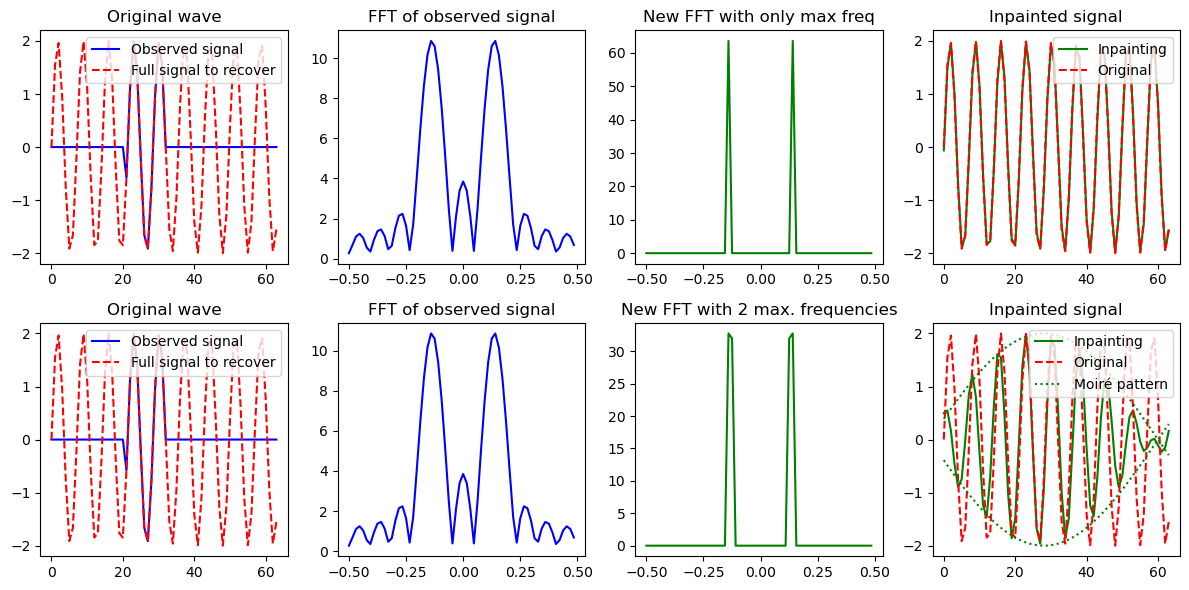

In [13]:
lr=[1,1,1,1]
base=3
N=64
fig,ax=plt.subplots(2,4,figsize=(base*sum(lr),2*base),gridspec_kw={'width_ratios': lr})


f0=2*math.pi*9/N
x=2*torch.sin(torch.arange(0,N,dtype=torch.float32)*f0).view(1,1,-1)
m=x*0.
m[:,:,N//3:N//2:]=1
x_observed=x*m
f_observed=fft.fft(x_observed)


fmax=f_observed.abs().max() 
f_new=f_observed*(f_observed.abs()==fmax) # keep max frequency only
f_new=f_new/f_new.norm()*f_observed.norm()*(m.mean())**-.5  # normalize enrgy
x_new=fft.ifft(f_new).real

f=fft.fft(x)
f_down=(f[...,0::2]+f[...,1::2])/2
x_down=fft.ifft(f_down).real
xm=x*1.
xm[N//2:]=0
fm=fft.fft(xm)
fmdown=(fm[...,0::2]+fm[...,1::2])/2


ax[0,0].plot(x_observed[0,0].cpu(),color='b',label='Observed signal')
ax[0,0].plot(x[0,0].cpu(),color='r',label='Full signal to recover',linestyle='--')
ax[0,0].set_title('Original wave')
ax[0,0].legend(loc='upper right')
ax[0,1].plot(fft.fftshift(fft.fftfreq(N)),fft.fftshift(torch.abs(f_observed[0,0]).cpu()),color='b')#,linestyle='')
ax[0,1].set_title('FFT of observed signal')
ax[0,2].plot(fft.fftshift(fft.fftfreq(N)),fft.fftshift(torch.abs(f_new[0,0]).cpu()),color='g')#,linestyle='')
ax[0,2].set_title('New FFT with only max freq')
ax[0,3].plot(x_new[0,0],color='g',label='Inpainting')#,linestyle='')
ax[0,3].plot(x[0,0].cpu(),color='r',label='Original',linestyle='--')
ax[0,3].set_title('Inpainted signal')
ax[0,3].legend(loc='upper right')






x=torch.sin(torch.arange(0,N,dtype=torch.float32)*f0).view(1,1,-1)*2
f_observed=fft.fft(x_observed)

fmax=f_observed.abs().max()
f_new=f_observed*(f_observed.abs()>=fmax*.95)
f_new=f_new/f_new.norm()**2*f_observed.norm()**2
x_new=fft.ifft(f_new).real

f=fft.fft(x)
f_down=(f[...,0::2]+f[...,1::2])/2
x_down=fft.ifft(f_down).real
xm=x*1.
xm[N//2:]=0
fm=fft.fft(xm)
fmdown=(fm[...,0::2]+fm[...,1::2])/2


ax[1,0].plot(x_observed[0,0].cpu(),color='b',label='Observed signal')
ax[1,0].plot(x[0,0].cpu(),color='r',label='Full signal to recover',linestyle='--')
ax[1,0].set_title('Original wave')
ax[1,0].legend(loc='upper right')
ax[1,1].plot(fft.fftshift(fft.fftfreq(N)),fft.fftshift(torch.abs(f_observed[0,0]).cpu()),color='b')#,linestyle='')
ax[1,1].set_title('FFT of observed signal')
ax[1,2].plot(fft.fftshift(fft.fftfreq(N)),fft.fftshift(torch.abs(f_new[0,0]).cpu()),color='g')#,linestyle='')
ax[1,2].set_title('New FFT with 2 max. frequencies')
ax[1,3].plot(x_new[0,0],color='g',label='Inpainting')#,linestyle='')
ax[1,3].plot(x[0,0].cpu(),color='r',label='Original',linestyle='--')
ax[1,3].plot(2*torch.sin(math.pi/8-math.pi/16+2*math.pi*torch.arange(N)/N/2),color='g',label='Moiré pattern',linestyle=':')
ax[1,3].plot(-2*torch.sin(math.pi/8-math.pi/16+2*math.pi*torch.arange(N)/N/2),color='g',linestyle=':')
ax[1,3].legend(loc='upper right')
ax[1,3].set_title('Inpainted signal')


plt.tight_layout()
plt.savefig(os.path.join(dir_fig, 'inpaint_max.png'), dpi=300)
plt.show()


# Images for scema (not included in the paper)
Results saved under `./images/figures/schema/`

In [ ]:
method='fomonms_size_3_EMN_1_CA_1'
img0='8'
B=1

for d in os.listdir('./runs'):
    if img0 == d.split('_')[1] and method in d:
        name=d
#print(name)
with torch.no_grad():
    parser = argparse.ArgumentParser()
    args ,_= parser.parse_known_args()
    args=load_args(os.path.join('./runs',name,'args.json'),args)
    torch.manual_seed(args.seed) if reproduce else torch.seed()
    FM.CA=args.CA
    FM.EMN=args.EMN
    dset=DS_rot(args.dataset_path,image_size=(args.img_size,args.img_size),min_mask_shape=(64,64),max_mask_shape=(200,200))
    loader=DataLoader(dset,batch_size=args.bs,shuffle=True,drop_last=True,num_workers=0)
    M = Model(nc_im=3,nc_start=args.dim,nc_max=512,depth=args.depth,fourier_mode=args.fourier_mode,train_size=(args.img_size,args.img_size),nms_size=args.nms_size).to(device)
    M.eval()



    x_plot,mask_plot=next(iter(loader))
    mask_plot=torch.zeros_like(mask_plot)
    mask_plot[:,0,64:192,64:192]=1.
    x_plot,mask_plot=x_plot.to(device),mask_plot.to(device)


    masked_plot=x_plot*mask_plot
    n_plot=torch.randn_like(masked_plot)
    b,c,h,w=x_plot.shape

    ratio=(2,2)
    x_plot2x=F.pad(x_plot,(((ratio[1]-1)*w)//2,((ratio[1]-1)*w)-((ratio[1]-1)*w)//2,((ratio[0]-1)*h)//2,((ratio[0]-1)*h)-((ratio[0]-1)*h)//2))
    mask_plot2x=F.pad(mask_plot,(((ratio[1]-1)*w)//2,((ratio[1]-1)*w)-((ratio[1]-1)*w)//2,((ratio[0]-1)*h)//2,((ratio[0]-1)*h)-((ratio[0]-1)*h)//2))
    masked_plot2x=x_plot2x*mask_plot2x
    n_plot2x=torch.randn_like(masked_plot2x)

    x_plot,mask_plot,masked_plot,n_plot=x_plot2x,mask_plot2x,masked_plot2x,n_plot2x
    try:
        M.load_state_dict(torch.load(os.path.join('runs',name,'M.pth')),strict=False) 
    except:
        print('model not loaded!')
        pass
    print(n_params(M)/10**6,'M parameters')

    if 'fomo' in args.fourier_mode.lower():
        lam=M.Fourier_module.block.lam 
        _,idx=torch.sort(lam.abs(),dim=1,descending=True)
        idx=idx.flatten()
        plt.figure(figsize=(10,5))
        plt.title('Distribution of $\lambda$ values in FoMo-NMS')
        plt.hist(lam.abs().cpu().flatten(),bins=20,density=True)
    


    # 
    save_image(masked_plot[0].cpu().detach(), os.path.join(dir_fig,'schema','input_1x.png'))

    x=M.enc(torch.cat((n_plot,masked_plot,mask_plot),dim=1))
    feat_in=x*1.
    lam=M.Fourier_module.block.lam
    pos_channel=torch.argmax(lam.abs(),dim=1).squeeze()

    
    batch, c, h, w = x.size()
    nms_size=M.Fourier_module.block.nms_size
    rho_x,rho_y=h//M.Fourier_module.block.ref_size[0],w//M.Fourier_module.block.ref_size[1]

    ffted = torch.fft.fft2(x-x.mean(dim=(2,3), keepdim=True), dim=(-2,-1), norm='backward')              # FFT2
    phase=torch.angle(ffted)                                             # Store phase for later
    
    mod=ffted.abs()
    norm=(mod**2).sum(dim=(-2,-1),keepdim=True)**.5                
    for i in range(4):
        save_image(x[0,idx[i]].cpu().detach(),os.path.join(dir_fig,'schema','features_1x_c%d.png') % i,normalize=True )
    #save_image(fft.fftshift(mod,dim=(-2,-1))[0,pos_channel].cpu().detach().numpy(), os.path.join(dir_fig,'schema','mod.png'))

    if True:
    
        mask = F.interpolate(mask_plot, (h, w), mode='nearest')  # (B,1,H,W)
        k = 3
        mask_pad = F.pad(mask, (k, k, k, k), mode='circular')
        eroded = -F.max_pool2d(-mask_pad, kernel_size=2*k+1, stride=1)
        eroded = eroded.expand_as(x)
        n1 = eroded.sum((2,3), keepdim=True).clamp(min=1)
        mean = (x * eroded).sum((2,3), keepdim=True) / n1  

        x= x*eroded -mean*eroded
    for i in range(4):
        save_image(.5+x[0,idx[i]].cpu().detach()/max(x[0,idx[i]].max(),-x[0,idx[i]].min()).cpu().detach(), os.path.join(dir_fig,'schema','features_EMN_1x_c%d.png') % i)

    ffted = torch.fft.fft2(x, dim=(-2,-1), norm='backward')              # FFT2
    phase=torch.angle(ffted)                                             # Store phase for later
    mod=ffted.abs()
    norm=(mod**2).sum(dim=(-2,-1),keepdim=True)**.5


    #plt.imshow(fft.fftshift(mod,dim=(-2,-1))[0,0].cpu().detach().numpy())
    #plt.show()
    
    for i in range(4):
        save_image(torch.log1p(mod[0,idx[i]]).cpu().detach(), os.path.join(dir_fig,'schema','mod_1x_c%d.png') % i,normalize=True )
    #Non maximum suppression: kernel size stretched to match a fixed ratio of input size
    mp_size=((nms_size*rho_x)//2*2+1,(nms_size*rho_y)//2*2+1)                                                # make NMS kernel size proportional to input size, and odd

    mp=nn.MaxPool2d(mp_size,stride=(1,1),padding=((nms_size*rho_x)//2,(nms_size*rho_y)//2))

    if True:
        mean_mod=(mod*lam).sum(dim=(1),keepdim=True)                                                        # NMS on the mean across channels, weighted with their learnable importance.
        
        nms_mask=(mp(fft.fftshift(mean_mod,dim=(-2,-1)))==fft.fftshift(mean_mod,dim=(-2,-1)))                    # Effectively compute the NMS mask in a periodic manner.
        nms_mask=fft.ifftshift(nms_mask,dim=(-2,-1))
        nms_mask=((mp(mean_mod)==mean_mod) * nms_mask)*1                        
        #nms_mask=nms_mask.repeat(1,c,1,1)       
    
    new_mod=mod*nms_mask       
    for i in range(4):
        save_image(torch.log1p(new_mod[0,idx[i]]).cpu().detach()**4, os.path.join(dir_fig,'schema','mod_NMS_CA_1x_c%d.png') % i,normalize=True )                                                                                     # Mask out non-maxima in the magnitude spectrum
    #plt.imshow(fft.fftshift(new_mod,dim=(-2,-1))[0,0].cpu().detach().numpy())
    #plt.show()
        

    new_mod=new_mod*norm/(new_mod**2).sum(dim=(-2,-1),keepdim=True)**.5*mask_plot.mean(dim=(2,3),keepdim=True)**-.5  # Mask-adaptive renormalization


    new_f = new_mod*torch.exp(1.j*phase)                               # re-inject the phase
    output = fft.ifft2(new_f,dim=(-2,-1),norm='backward').real         # iFTTT2
    res = output*lam.abs()   
    for i in range(4):
        save_image(res[0,idx[i]].cpu().detach(), os.path.join(dir_fig,'schema','out_1x_c%d.png') % i,normalize=True )




    out=torch.sigmoid(M.dec(feat_in+res))
    save_image(out[0].cpu().detach(), os.path.join(dir_fig,'schema','rec_1x.png'))


















### Old code for visualization

In [ ]:
methods=['fomonms_size_3_EMN_1_CA_1','FU','UFU','Vanilla']#,'Attention'
B=8
col=4
for img0 in [str(i) for i in range(1,16)]:
    for method in methods:
        for d in os.listdir('./runs'):
            if  img0 == d.split('_')[0]  and method in d:
                if method=='FU' and not 'UFU' in d:
                    name=dtorch.man
                    break
                name=d
        #print(name,method)
        if method=='Attention':
            pass
            #continue

        with torch.no_grad():
            parser = argparse.ArgumentParser()
            args ,_= parser.parse_known_args()
            args=load_args(os.path.join('./runs',name,'args.json'),args)
            torch.manual_seed(args.seed) if reproduce else torch.seed()
            dir_inf=os.path.join('runs',name,'inference')
            os.makedirs(dir_inf,exist_ok=True)
            
            FM.CA=args.CA
            FM.EMN=args.EMN
            dset=DS_rot(args.dataset_path,image_size=(args.img_size,args.img_size),min_mask_shape=(64,64),max_mask_shape=(200,200))
            loader=DataLoader(dset,batch_size=args.bs,shuffle=True,drop_last=True,num_workers=0)
            M = Model(nc_im=3,nc_start=args.dim,nc_max=512,depth=args.depth,fourier_mode=args.fourier_mode,train_size=(args.img_size,args.img_size),nms_size=args.nms_size).to(device)
            M.eval()

            x_plot,mask_plot=next(iter(loader))
            x_plot,mask_plot=x_plot.to(device),mask_plot.to(device)
            masked_plot=x_plot*mask_plot
            n_plot=torch.randn_like(masked_plot)
            b,c,h,w=x_plot.shape

            ratio=(2,2)
            x_plot2x=F.pad(x_plot,(((ratio[1]-1)*w)//2,((ratio[1]-1)*w)-((ratio[1]-1)*w)//2,((ratio[0]-1)*h)//2,((ratio[0]-1)*h)-((ratio[0]-1)*h)//2))
            mask_plot2x=F.pad(mask_plot,(((ratio[1]-1)*w)//2,((ratio[1]-1)*w)-((ratio[1]-1)*w)//2,((ratio[0]-1)*h)//2,((ratio[0]-1)*h)-((ratio[0]-1)*h)//2))
            masked_plot2x=x_plot2x*mask_plot2x
            n_plot2x=torch.randn_like(masked_plot2x)


            try:
                M.load_state_dict(torch.load(os.path.join('runs',name,'M.pth')),strict=False) 
            except:
                print('model not loaded!')
                pass
            #print(n_params(M)/10**6,'M parameters')

            if 'fomo' in args.fourier_mode.lower():
                lam=M.Fourier_module.block.lam 
                _,idx=torch.sort(lam.abs(),dim=1,descending=True)
                plt.figure(figsize=(10,5))
                plt.title('Distribution of $\lambda$ values in FoMo-NMS')
                plt.hist(lam.abs().cpu().numpy().flatten(),bins=20,density=True)


            # base size
            rec=M(n_plot,mask_plot,masked_plot)
            im= torch.cat((make_grid(x_plot+.3*mask_plot),make_grid(rec)),dim=-2).cpu()
            save_image(im,os.path.join(dir_inf,'%s.png'%args.fourier_mode))

            f=FM.features['%s_in'%args.fourier_mode]
            if 'fomo' in args.fourier_mode.lower(): 
                f=f[:,idx.view(-1)]
            fmin,fmax=f.view(f.shape[0],f.shape[1],-1).sort(dim=-1)[0][...,20:-20].min(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1),f.view(f.shape[0],f.shape[1],-1).sort(dim=-1)[0][...,100:-100].max(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1)
            f_in=((f-fmin)/(fmax-fmin)).clamp(0,1)
            m=torch.log1p(fft.fftshift(fft.fft2(f-f.mean(dim=(-2,-1)).unsqueeze(-1).unsqueeze(-1),norm='backward'),dim=(-2,-1)).abs())
            m=(m-m.view(m.shape[0],m.shape[1],-1).min(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1))/(m.view(m.shape[0],m.shape[1],-1).max(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1)-m.view(m.shape[0],m.shape[1],-1).min(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1))
            m_in=1.*m

            f=FM.features['%s_out'%args.fourier_mode]
            if 'fomo' in args.fourier_mode.lower():
                f=f[:,idx.view(-1)]
            fmin,fmax=f.view(f.shape[0],f.shape[1],-1).sort(dim=-1)[0][...,20:-20].min(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1),f.view(f.shape[0],f.shape[1],-1).sort(dim=-1)[0][...,100:-100].max(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1)
            f_out=((f-fmin)/(fmax-fmin)).clamp(0,1)
            m=torch.log1p(fft.fftshift(fft.fft2(f-f.mean(dim=(-2,-1)).unsqueeze(-1).unsqueeze(-1),norm='backward'),dim=(-2,-1)).abs())
            tmp = torch.where(m >1e-4, m, torch.full_like(m, float('inf')))
            min_vals = tmp.amin(dim=(-2, -1), keepdim=True)
            m = torch.where(m > 1e-4, m, m - min_vals)
            m_out=(m-m.view(m.shape[0],m.shape[1],-1).min(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1))/(m.view(m.shape[0],m.shape[1],-1).max(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1)-m.view(m.shape[0],m.shape[1],-1).min(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1))
            m_out=m_out**4

            fm=torch.cat((torch.cat([f_in,f_out],dim=-2),torch.cat([m_in,m_out],dim=-2)),dim=-1)
            fm=F.interpolate(fm,size=(rec.shape[-2]//1,2*x_plot.shape[-1]//2),mode='nearest')
            for b in range(B):
                img = rec[b:b+1].clone()  
                mask = mask_plot[b] 
                ys, xs = torch.where(mask[0] > 0)
                y1, y2 = ys.min(), ys.max()
                x1, x2 = xs.min(), xs.max()
                for t in [0, 1]:
                    img[:, 0, y1:y2+1, x1+t] = 0.0
                    img[:, 0, y1:y2+1, x2-t] = 0.0
                    img[:, 0, y1+t, x1:x2+1] = 0.0
                    img[:, 0, y2-t, x1:x2+1] = 0.0
                    img[:, 1:, y1:y2+1, x1+t] = 0
                    img[:, 1:, y1:y2+1, x2-t] = 0
                    img[:, 1:, y1+t, x1:x2+1] = 0
                    img[:, 1:, y2-t, x1:x2+1] = 0
                i1 = make_grid(img,nrow=1,padding=0)
                i2 = make_grid(torch.cat([fm[b, i] for i in range(col)], dim=-1).unsqueeze(0).unsqueeze(1).repeat(1, 3, 1, 1),nrow=1,padding=0)
                grid = torch.cat([i1, i2], dim=-1).permute(0,2,1)
                os.makedirs(os.path.join(dir_inf,str(b)),exist_ok=True)
                save_image(grid.permute(0, 2, 1),os.path.join(dir_inf,str(b), "%s.png"%args.fourier_mode))




            # extended size
            rec=M(n_plot2x,mask_plot2x,masked_plot2x)
            im= torch.cat((make_grid(x_plot2x+.3*mask_plot2x),make_grid(rec)),dim=-2).cpu()
            save_image(im,os.path.join(dir_inf,'%s_2x.png'%args.fourier_mode))

            f=FM.features['%s_in'%args.fourier_mode]
            if 'fomo' in args.fourier_mode.lower():
                f=f[:,idx.view(-1)]
            fmin,fmax=f.view(f.shape[0],f.shape[1],-1).sort(dim=-1)[0][...,20:-20].min(dim=-1)[0].unsqueeze(-1).unsqueeze(-1),f.view(f.shape[0],f.shape[1],-1).sort(dim=-1)[0][...,100:-100].max(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1)
            f_in=((f-fmin)/(fmax-fmin)).clamp(0,1)
            m=torch.log1p(fft.fftshift(fft.fft2(f-f.mean(dim=(-2,-1)).unsqueeze(-1).unsqueeze(-1),norm='backward'),dim=(-2,-1)).abs())
            m=(m-m.view(m.shape[0],m.shape[1],-1).min(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1))/(m.view(m.shape[0],m.shape[1],-1).max(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1)-m.view(m.shape[0],m.shape[1],-1).min(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1))
            m_in=1.*m

            f=FM.features['%s_out'%args.fourier_mode]
            if 'fomo' in args.fourier_mode.lower():
                f=f[:,idx.view(-1)]
            fmin,fmax=f.view(f.shape[0],f.shape[1],-1).sort(dim=-1)[0][...,20:-20].min(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1),f.view(f.shape[0],f.shape[1],-1).sort(dim=-1)[0][...,100:-100].max(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1)
            f_out=((f-fmin)/(fmax-fmin)).clamp(0,1)
            m=torch.log1p(fft.fftshift(fft.fft2(f-f.mean(dim=(-2,-1)).unsqueeze(-1).unsqueeze(-1),norm='backward'),dim=(-2,-1)).abs())
            tmp = torch.where(m >1e-4, m, torch.full_like(m, float('inf')))
            min_vals = tmp.amin(dim=(-2, -1), keepdim=True)
            m = torch.where(m > 1e-4, m, m - min_vals)
            m_out=(m-m.view(m.shape[0],m.shape[1],-1).min(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1))/(m.view(m.shape[0],m.shape[1],-1).max(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1)-m.view(m.shape[0],m.shape[1],-1).min(dim=(-1))[0].unsqueeze(-1).unsqueeze(-1))
            m_out=m_out**4

            fm=torch.cat((torch.cat([f_in,f_out],dim=-2),torch.cat([m_in,m_out],dim=-2)),dim=-1)
            #fm=torch.cat([f_in,f_out],dim=-2)
            fm=F.interpolate(fm,size=(rec.shape[-2]//1,2*x_plot2x.shape[-1]//2),mode='nearest')
            for b in range(B):
                img = rec[b:b+1].clone()  
                mask = mask_plot2x[b]
                ys, xs = torch.where(mask[0] > 0)
                y1, y2 = ys.min(), ys.max()
                x1, x2 = xs.min(), xs.max()
                for t in [0, 1]:
                    img[:, 0, y1:y2+1, x1+t] = 0.0
                    img[:, 0, y1:y2+1, x2-t] = 0.0
                    img[:, 0, y1+t, x1:x2+1] = 0.0
                    img[:, 0, y2-t, x1:x2+1] = 0.0
                    img[:, 1:, y1:y2+1, x1+t] = 0
                    img[:, 1:, y1:y2+1, x2-t] = 0
                    img[:, 1:, y1+t, x1:x2+1] = 0
                    img[:, 1:, y2-t, x1:x2+1] = 0
                i1 = make_grid(img,nrow=1,padding=0)
                i2 = make_grid(torch.cat([fm[b, i] for i in range(col)], dim=-1).unsqueeze(0).unsqueeze(1).repeat(1, 3, 1, 1),nrow=1,padding=0)
                grid = torch.cat([i1, i2], dim=-1).permute(0,2,1)
                os.makedirs(os.path.join(dir_inf,str(b)),exist_ok=True)
                save_image(grid.permute(0, 2, 1),os.path.join(dir_inf,str(b), "%s_2x.png"%args.fourier_mode))








